# 01 – EDA & Data Cleaning
**Author:** Subin (Person 1)

| Section | What |
|---------|------|
| 1 | Imports & setup |
| 2 | Load raw data |
| 3 | Null audit |
| 4 | Run cleaning pipeline |
| 5 | Save cleaned data |
| 6 | EDA – Ticket type distribution |
| 7 | EDA – Text length analysis |

## 1. Imports & setup

In [41]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(''), '..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_cleaning import (
    load_raw_data,
    null_report,
    clean_tickets,
    save_clean_data,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13})

RAW_PATH   = '../data/raw/customer_support_tickets.csv'
CLEAN_PATH = '../data/processed/tickets_cleaned.csv'
FIG_DIR    = '../reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)

## 2. Load raw data

In [42]:
df_raw = load_raw_data(RAW_PATH)
print(f"Shape   : {df_raw.shape}")
print(f"Columns : {df_raw.columns.tolist()}")
df_raw.head(3)

10:30:18  INFO  Loaded customer_support_tickets.csv | shape (8469, 17)


Shape   : (8469, 17)
Columns : ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [43]:
df_raw.dtypes

Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
First Response Time              object
Time to Resolution               object
Customer Satisfaction Rating    float64
dtype: object

## 3. Null audit (pre-cleaning)

In [44]:
report = null_report(df_raw)
print(f"{len(report)} columns have missing values\n")
report

4 columns have missing values



,null_count,null_%
Resolution,5700,67.30
First Response Time,2819,33.29
Time to Resolution,5700,67.30
Customer Satisfaction Rating,5700,67.30


## 4. Run cleaning pipeline

In [45]:
df = clean_tickets(df_raw.copy())
df.head(3)

10:30:18  INFO  Starting cleaning pipeline...
10:30:18  INFO  Duplicates removed: 0 | rows remaining: 8469
10:30:18  INFO  Dropped PII: ['Customer Name', 'Customer Email']
10:30:18  INFO  Date features extracted.
10:30:18  INFO  Missing values filled.
10:30:18  INFO  Placeholders replaced.
10:30:18  INFO  Dtypes cast | raw datetime cols dropped.
10:30:18  INFO  Pipeline complete | final shape: (8469, 21)


,Ticket ID,Customer Age,Customer Gender,Product Purchased,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,...,Customer Satisfaction Rating,purchase_year,purchase_month,purchase_day,purchase_dow,first_response_hour,has_first_response,resolution_hour,is_resolved,satisfaction_rated_flag
0,1,32,Other,GoPro Hero,Technical issue,Product setup,I'm having an issue with the GoPro Hero. Pleas...,Pending Customer Response,Pending,Critical,...,0.0,2021,3,22,0,12,1,-1,0,0
1,2,42,Female,LG Smart TV,Technical issue,Peripheral compatibility,I'm having an issue with the LG Smart TV. Plea...,Pending Customer Response,Pending,Critical,...,0.0,2021,5,22,5,16,1,-1,0,0
2,3,48,Other,Dell XPS,Technical issue,Network problem,I'm facing a problem with my Dell XPS. The Del...,Closed,Case maybe show recently my computer follow.,Low,...,3.0,2020,7,14,1,11,1,18,1,1


In [46]:
print(f"Shape : {df.shape}")
print(f"Nulls : {df.isnull().sum().sum()}")
df.dtypes

Shape : (8469, 21)
Nulls : 0


Ticket ID                         int64
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
Customer Satisfaction Rating    float64
purchase_year                     int64
purchase_month                    int64
purchase_day                      int64
purchase_dow                      int64
first_response_hour               int64
has_first_response                int64
resolution_hour                   int64
is_resolved                       int64
satisfaction_rated_flag           int64
dtype: object

## 5. Save cleaned data

In [47]:
save_clean_data(df, CLEAN_PATH)
print(f"Saved → {CLEAN_PATH}")

10:30:18  INFO  Saved ..\data\processed\tickets_cleaned.csv | shape (8469, 21) | nulls 0


Saved → ../data/processed/tickets_cleaned.csv


## 6. EDA – Ticket type distribution

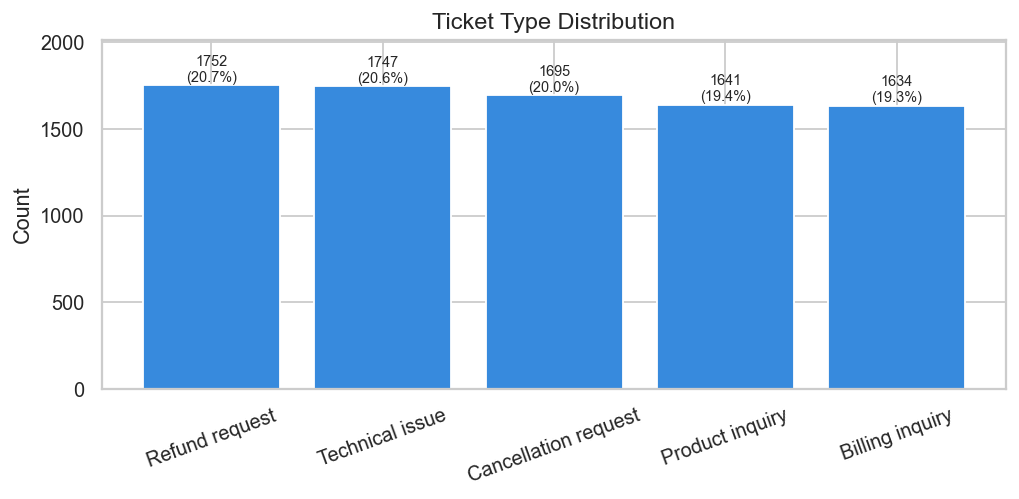

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


In [48]:
tt = df['Ticket Type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tt.index, tt.values, color='#378ADD', edgecolor='white')
ax.set_title('Ticket Type Distribution')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
ax.set_ylim(0, max(tt.values) * 1.15)

for i, v in enumerate(tt.values):
    ax.text(i, v + 20, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_ticket_type_distribution.png', dpi=150)
plt.show()
print(tt)

## 7. EDA – Text length analysis

In [49]:
df['text_length'] = df['Ticket Description'].str.len()

print('=== Text Length Stats ===')
print(df['text_length'].describe().round(1))

=== Text Length Stats ===
count    8469.0
mean      282.0
std        44.0
min       135.0
25%       263.0
50%       290.0
75%       310.0
max       402.0
Name: text_length, dtype: float64


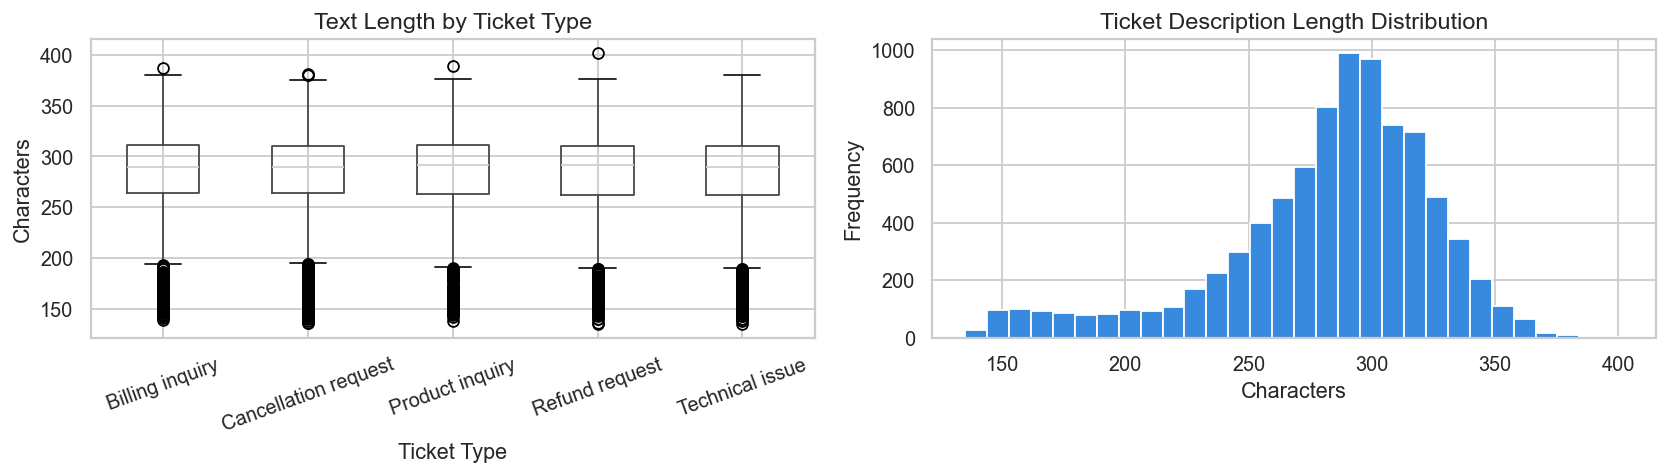

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot: length by ticket type
df.boxplot(column='text_length', by='Ticket Type', ax=axes[0])
axes[0].set_title('Text Length by Ticket Type')
axes[0].set_xlabel('Ticket Type')
axes[0].set_ylabel('Characters')
axes[0].tick_params(axis='x', rotation=20)

# Histogram: overall distribution
axes[1].hist(df['text_length'], bins=30, color='#378ADD', edgecolor='white')
axes[1].set_title('Ticket Description Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')

plt.suptitle('')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_text_length_analysis.png', dpi=150)
plt.show()